<a href="https://colab.research.google.com/github/Vivekreddy1201/Breed-Classification-of-Cattle/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import re
import random
import kagglehub

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Download latest version
dataset1 = kagglehub.dataset_download("lukex9442/indian-bovine-breeds")

print("Path to dataset files:", dataset1)

100%|██████████| 2.84G/2.84G [00:27<00:00, 109MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lukex9442/indian-bovine-breeds/versions/5


In [ ]:
# Download latest version
dataset2 = kagglehub.dataset_download("atharvadarpude/indian-buffalo-dataset")

print("Path to dataset files:", dataset2)

100%|██████████| 38.4M/38.4M [00:00<00:00, 81.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/atharvadarpude/indian-buffalo-dataset/versions/1


In [ ]:
# Download datasets
dataset1 = kagglehub.dataset_download("lukex9442/indian-bovine-breeds")
dataset2 = kagglehub.dataset_download("atharvadarpude/indian-buffalo-dataset")

print("Dataset1:", dataset1)
print("Dataset2:", dataset2)

# Fix paths according to dataset structure
dataset1 = os.path.join(dataset1, "Indian_bovine_breeds", "Indian_bovine_breeds")
dataset2 = os.path.join(dataset2, "buffalo")

# Final merged dataset
final_dataset = "final_dataset"
os.makedirs(final_dataset, exist_ok=True)

def normalize(name):
    name = name.lower()
    name = name.replace(" ", "_")
    name = name.replace("-", "_")
    name = re.sub(r'[^a-z0-9_]', '', name)
    if name == 'jaffrabadi':
        name = 'jaffarabadi'
    if name == 'bhadwari':
        name = 'bhadawari'
    return name

def merge_dataset(source):

    for breed in os.listdir(source):

        breed_path = os.path.join(source, breed)

        if not os.path.isdir(breed_path):
            continue

        breed_name = normalize(breed)

        final_breed_path = os.path.join(final_dataset, breed_name)
        os.makedirs(final_breed_path, exist_ok=True)

        for img in os.listdir(breed_path):

            src = os.path.join(breed_path, img)

            if not os.path.isfile(src):
                continue

            dst = os.path.join(final_breed_path, img)

            if os.path.exists(dst):
                name, ext = os.path.splitext(img)
                dst = os.path.join(final_breed_path, name + "_copy" + ext)

            shutil.copy2(src, dst)

merge_dataset(dataset1)
merge_dataset(dataset2)

print("Datasets merged successfully!")

Dataset1: /root/.cache/kagglehub/datasets/lukex9442/indian-bovine-breeds/versions/5
Dataset2: /root/.cache/kagglehub/datasets/atharvadarpude/indian-buffalo-dataset/versions/1
Datasets merged successfully!


In [ ]:
# import shutil

# shutil.make_archive(
#     "/kaggle/working/final_dataset",
#     'zip',
#     "/kaggle/working/final_dataset"
# )

In [ ]:
dataset = "final_dataset"

for breed in sorted(os.listdir(dataset)):
    path = os.path.join(dataset, breed)
    if os.path.isdir(path):
        print(breed, ":", len(os.listdir(path)))

alambadi : 99
amritmahal : 94
ayrshire : 234
banni : 236
bargur : 217
bhadawari : 234
brown_swiss : 225
chhattisgarhi : 131
chilika : 144
dangi : 82
deoni : 99
gir : 372
gojri : 177
guernsey : 119
hallikar : 186
hariana : 130
holstein_friesian : 328
jaffarabadi : 459
jersey : 203
kalahandi : 67
kangayam : 91
kankrej : 179
kasargod : 95
kenkatha : 55
kherigarh : 36
khillari : 113
krishna_valley : 136
luit : 129
malnad_gidda : 107
marathwada : 172
mehsana : 163
murrah : 499
nagori : 89
nagpuri : 343
nili_ravi : 278
nimari : 84
ongole : 191
pandharpuri : 141
pulikulam : 125
rathi : 149
red_dane : 167
red_sindhi : 166
sahiwal : 439
surti : 234
tharparkar : 217
toda : 285
umblachery : 76
vechur : 140


In [ ]:
selected_breeds = [
    "gir","sahiwal","ongole","kankrej","tharparkar","hallikar",
    "jersey","holstein_friesian","brown_swiss",
    "murrah","nagpuri","jaffarabadi","nili_ravi","surti","mehsana"
]

In [ ]:
source_dataset = "final_dataset"
filtered_dataset = "filtered_dataset"

# Remove filtered_dataset if it exists to ensure a clean start
if os.path.exists(filtered_dataset):
    shutil.rmtree(filtered_dataset)

os.makedirs(filtered_dataset, exist_ok=True)

for breed in selected_breeds:

    src = os.path.join(source_dataset, breed)
    dst = os.path.join(filtered_dataset, breed)

    if os.path.exists(src):
        shutil.copytree(src, dst)

print("Filtered dataset created!")

Filtered dataset created!


In [ ]:
import os

cropped_dataset = "filtered_dataset"
total_images = 0

for breed in os.listdir(cropped_dataset):
    breed_path = os.path.join(cropped_dataset, breed)
    if os.path.isdir(breed_path):
        num_images = len(os.listdir(breed_path))
        print(f"Breed: {breed}, Images: {num_images}")
        total_images += num_images

print(f"\nTotal images in cropped_dataset: {total_images}")

Breed: ongole, Images: 191
Breed: gir, Images: 372
Breed: nili_ravi, Images: 278
Breed: holstein_friesian, Images: 328
Breed: jaffarabadi, Images: 459
Breed: brown_swiss, Images: 225
Breed: mehsana, Images: 163
Breed: sahiwal, Images: 439
Breed: surti, Images: 234
Breed: murrah, Images: 499
Breed: jersey, Images: 203
Breed: hallikar, Images: 186
Breed: nagpuri, Images: 343
Breed: kankrej, Images: 179
Breed: tharparkar, Images: 217

Total images in cropped_dataset: 4316


**APPLYING YOLO**

In [ ]:
import cv2
import shutil
from ultralytics import YOLO

In [ ]:
model = YOLO("yolov8n.pt")   # lightweight and fast

In [ ]:
input_dataset = "filtered_dataset"
output_dataset = "cropped_dataset"

# Reset output folder
if os.path.exists(output_dataset):
    shutil.rmtree(output_dataset)

os.makedirs(output_dataset, exist_ok=True)

In [ ]:
for breed in os.listdir(input_dataset):
    breed_path = os.path.join(input_dataset, breed)
    save_path = os.path.join(output_dataset, breed)

    os.makedirs(save_path, exist_ok=True)

    for img_name in os.listdir(breed_path):
        img_path = os.path.join(breed_path, img_name)

        try:
            image = cv2.imread(img_path)
            if image is None:
                continue

            results = model(img_path)

            for result in results:
                boxes = result.boxes.xyxy
                confs = result.boxes.conf

                if boxes is None or len(boxes) == 0:
                    continue

                # BEST detection (high confidence)
                best_idx = confs.argmax()
                x1, y1, x2, y2 = map(int, boxes[best_idx])

                crop = image[y1:y2, x1:x2]

                if crop.size == 0:
                    continue

                save_file = os.path.join(save_path, img_name)
                cv2.imwrite(save_file, crop)

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

print("Cropped dataset created successfully!")

Streaming output truncated to the last 5000 lines.
Speed: 3.7ms preprocess, 13.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/filtered_dataset/surti/Buy_Murrah_Buffalo_at_Wholesale_Price_ (1).jpg: 640x640 (no detections), 11.9ms
Speed: 4.2ms preprocess, 11.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/filtered_dataset/surti/image_225x225_6.jpg: 640x640 5 persons, 2 cows, 3 elephants, 11.1ms
Speed: 4.1ms preprocess, 11.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/filtered_dataset/surti/Indian_Black_Murrah_Buffalo_Price_.jpg: 640x640 2 horses, 1 cow, 11.8ms
Speed: 3.0ms preprocess, 11.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/filtered_dataset/surti/image_261x193_1.jpg: 480x640 1 cow, 11.6ms
Speed: 2.3ms preprocess, 11.6ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/filtered_

In [ ]:
import os

cropped_dataset = "cropped_dataset"
total_images = 0

for breed in os.listdir(cropped_dataset):
    breed_path = os.path.join(cropped_dataset, breed)
    if os.path.isdir(breed_path):
        num_images = len(os.listdir(breed_path))
        print(f"Breed: {breed}, Images: {num_images}")
        total_images += num_images

print(f"\nTotal images in cropped_dataset: {total_images}")

Breed: ongole, Images: 188
Breed: gir, Images: 369
Breed: nili_ravi, Images: 261
Breed: holstein_friesian, Images: 315
Breed: jaffarabadi, Images: 418
Breed: brown_swiss, Images: 213
Breed: mehsana, Images: 149
Breed: sahiwal, Images: 436
Breed: surti, Images: 216
Breed: murrah, Images: 458
Breed: jersey, Images: 193
Breed: hallikar, Images: 181
Breed: nagpuri, Images: 319
Breed: kankrej, Images: 177
Breed: tharparkar, Images: 213

Total images in cropped_dataset: 4106


In [ ]:
from sklearn.model_selection import train_test_split
import shutil

train_dir = "data/train"
val_dir = "data/val"

for breed in os.listdir(output_dataset):
    breed_path = os.path.join(output_dataset, breed)
    images = os.listdir(breed_path)

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, breed), exist_ok=True)
    os.makedirs(os.path.join(val_dir, breed), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(breed_path, img),
                    os.path.join(train_dir, breed, img))

    for img in val_imgs:
        shutil.copy(os.path.join(breed_path, img),
                    os.path.join(val_dir, breed, img))

print("Train/Val split done!")

Train/Val split done!


AUGMENTATION OF DATA

In [ ]:
train_dir = "data/train"
val_dir = "data/val"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 3264 images belonging to 15 classes.
Found 828 images belonging to 15 classes.


In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# classes = np.unique(train_generator.classes)

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=classes,
#     y=train_generator.classes
# )

# class_weights = dict(enumerate(class_weights))

# print(class_weights)

In [ ]:
print(train_generator.num_classes)

15


In [ ]:
print(train_generator.class_indices)

{'brown_swiss': 0, 'gir': 1, 'hallikar': 2, 'holstein_friesian': 3, 'jaffarabadi': 4, 'jersey': 5, 'kankrej': 6, 'mehsana': 7, 'murrah': 8, 'nagpuri': 9, 'nili_ravi': 10, 'ongole': 11, 'sahiwal': 12, 'surti': 13, 'tharparkar': 14}


In [ ]:
x, y = next(train_generator)
print(x.shape)
print(y.shape)

(32, 224, 224, 3)
(32, 15)


TRANSFER LEARNING

In [ ]:
num_classes = train_generator.num_classes

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss = "categorical_crossentropy",
    metrics=['accuracy']
)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    verbose = 1,
    callbacks=[checkpoint, early_stop, lr_reduce]
)

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.1414 - loss: 2.6554
Epoch 1: val_accuracy improved from None to 0.34541, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 104s 674ms/step - accuracy: 0.1982 - loss: 2.5295 - val_accuracy: 0.3454 - val_loss: 2.1848 - learning_rate: 1.0000e-04
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.3213 - loss: 2.1734
Epoch 2: val_accuracy improved from 0.34541 to 0.44324, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 496ms/step - accuracy: 0.3339 - loss: 2.0919 - val_accuracy: 0.4432 - val_loss: 1.7958 - learning_rate: 1.0000e-04
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.3801 - loss: 1.8882
Epoch 3: val_accuracy improved from 0.44324 to 0.50121, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 491ms/step - accuracy: 0.3909 - loss: 1.8262 - val_accuracy: 0.5012 - val_loss: 1.5747 - learning_rate: 1.0000e-04
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.4254 - loss: 1.7199
Epoch 4: val_accuracy improved from 0.50121 to 0.53502, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 504ms/step - accuracy: 0.4332 - loss: 1.6865 - val_accuracy: 0.5350 - val_loss: 1.4533 - learning_rate: 1.0000e-04
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.4669 - loss: 1.5570
Epoch 5: val_accuracy improved from 0.53502 to 0.55193, saving model to best_model.h5


...


Epoch 9: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 498ms/step - accuracy: 0.5466 - loss: 1.3197 - val_accuracy: 0.6087 - val_loss: 1.2203 - learning_rate: 1.0000e-04
Epoch 10/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.5440 - loss: 1.3407
Epoch 10: val_accuracy improved from 0.60870 to 0.61715, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 501ms/step - accuracy: 0.5585 - loss: 1.3124 - val_accuracy: 0.6171 - val_loss: 1.1964 - learning_rate: 1.0000e-04
Epoch 11/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.5635 - loss: 1.2727
Epoch 11: val_accuracy did not improve from 0.61715
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 493ms/step - accuracy: 0.5674 - loss: 1.2650 - val_accuracy: 0.6123 - val_loss: 1.1849 - learning_rate: 1.0000e-04
Epoch 12/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.5859 - loss: 1.2334
Epoch 12: val_accuracy improved from 0.61715 to 0.63527, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 498ms/step - accuracy: 0.5861 - loss: 1.2304 - val_accuracy: 0.6353 - val_loss: 1.1630 - learning_rate: 1.0000e-04
Epoch 13/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.5873 - loss: 1.1902
Epoch 13: val_accuracy did not improve from 0.63527
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 491ms/step - accuracy: 0.5925 - loss: 1.1968 - val_accuracy: 0.6208 - val_loss: 1.1513 - learning_rate: 1.0000e-04
Epoch 14/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.6055 - loss: 1.1677
Epoch 14: val_accuracy did not improve from 0.63527
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 494ms/step - accuracy: 0.6051 - loss: 1.1752 - val_accuracy: 0.6184 - val_loss: 1.1502 - learning_rate: 1.0000e-04
Epoch 15/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.6259 - loss: 1.1337
Epoch 15: val_accuracy did not improve from 0.63527
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 495ms/step - accuracy: 0.6167 - loss: 1.1497 - val


Epoch 18: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 510ms/step - accuracy: 0.6385 - loss: 1.0717 - val_accuracy: 0.6425 - val_loss: 1.1047 - learning_rate: 1.0000e-04
Epoch 19/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.6270 - loss: 1.1024
Epoch 19: val_accuracy improved from 0.64251 to 0.64734, saving model to best_model.h5



Epoch 19: finished saving model to best_model.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 500ms/step - accuracy: 0.6351 - loss: 1.0782 - val_accuracy: 0.6473 - val_loss: 1.1008 - learning_rate: 1.0000e-04
Epoch 20/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.6507 - loss: 1.0470
Epoch 20: val_accuracy did not improve from 0.64734
102/102 ━━━━━━━━━━━━━━━━━━━━ 81s 497ms/step - accuracy: 0.6449 - loss: 1.0448 - val_accuracy: 0.6461 - val_loss: 1.0832 - learning_rate: 1.0000e-04


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")

FINE TUNING

In [ ]:
for layer in base_model.layers[-15:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, lr_reduce],
    verbose = 1
)

Epoch 1/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 596ms/step - accuracy: 0.6532 - loss: 1.0307 - val_accuracy: 0.6437 - val_loss: 1.0921 - learning_rate: 1.0000e-05
Epoch 2/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.6382 - loss: 1.0431 - val_accuracy: 0.6401 - val_loss: 1.0903 - learning_rate: 1.0000e-05
Epoch 3/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 49s 484ms/step - accuracy: 0.6474 - loss: 1.0327 - val_accuracy: 0.6401 - val_loss: 1.0893 - learning_rate: 3.0000e-06


In [ ]:
os.makedirs('/kaggle/working', exist_ok=True)
model.save("/kaggle/working/model_backup.keras")

In [ ]:
import os
os.listdir("/kaggle/working")

['cattle_breed_model.keras']

In [ ]:
model = load_model("/kaggle/working/cattle_breed_model.keras")

IF RUNTIME REGENERATED

In [ ]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications.efficientnet import preprocess_input

# val_datagen = ImageDataGenerator(
#     preprocessing_function=preprocess_input
# )

# val_generator = val_datagen.flow_from_directory(
#     val_dir,
#     target_size=(224,224),
#     batch_size=32,
#     class_mode='categorical',
#     shuffle=False
# )

In [ ]:
loss, acc = model.evaluate(val_generator)

print("Validation Accuracy:", acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 288ms/step - accuracy: 0.6473 - loss: 1.1008
Validation Accuracy: 0.6473429799079895


In [ ]:
loss, acc = model.evaluate(train_generator)

print( "Training Accuracy:", acc)

102/102 ━━━━━━━━━━━━━━━━━━━━ 46s 454ms/step - accuracy: 0.7396 - loss: 0.8390
Training Accuracy: 0.7395833134651184


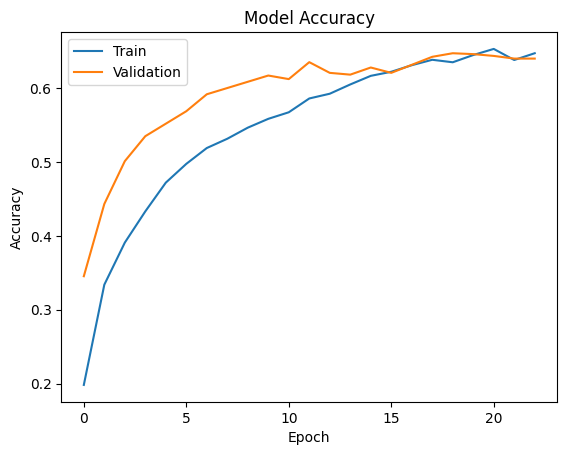

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

PREDICT

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/Gir_1.jfif"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

pred = model.predict(img_array)

predicted_class = np.argmax(pred)

labels = val_generator.class_indices
labels = dict((v,k) for k,v in labels.items())

print("Predicted Breed:", labels[predicted_class])

In [ ]:
plt.imshow(img)
plt.title("Predicted: " + labels[predicted_class])
plt.axis("off")
plt.show()

In [ ]:
import shutil
shutil.copy("/kaggle/working/cattle_breed_model.keras", "/kaggle/working/model_backup.keras")

**USING MODEL BY IMPORTING**

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/model_backup.keras")

In [ ]:
labels = [
'brown_swiss','gir','hallikar','holstein_friesian','jaffarabadi',
'jersey','kankrej','mehsana','murrah','nagpuri',
'nili_ravi','ongole','sahiwal','surti','tharparkar'
]

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = "/content/ongole1.jfif"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)

predicted_class = np.argmax(pred)

labels = [
'brown_swiss','gir','hallikar','holstein_friesian','jaffarabadi',
'jersey','kankrej','mehsana','murrah','nagpuri',
'nili_ravi','ongole','sahiwal','surti','tharparkar'
]

print("Predicted Breed:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Breed: ongole


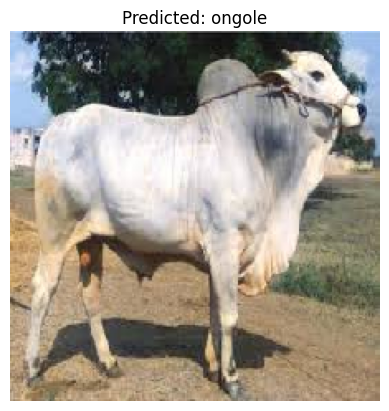

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Predicted: " + labels[predicted_class])
plt.axis("off")
plt.show()